In [1]:
# Color Image Quantization
Reduce the number of colors in images (`lena.png`, `peppers.tif`) to 16 using K-means clustering, implemented from scratch. Log L2 norms per iteration and optionally visualize quantized images.

SyntaxError: invalid syntax (ipython-input-260818336.py, line 2)

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def kmeans_quantization(image, k=16, max_iterations=100, visualize=False):
    """
    Perform K-means color quantization on an image.

    Args:
        image: Input image (H, W, 3) as float32 in [0, 1].
        k: Number of clusters (colors).
        max_iterations: Maximum number of iterations.
        visualize: If True, display quantized image per iteration.

    Returns:
        quantized_image: Image with k colors.
        l2_norms: List of quantization errors (sum of squared distances) per iteration.
    """
    # 1. Reshape image to a list of pixels (N, 3) where N = H * W
    pixels = image.reshape((-1, 3))

    # 2. Initialize k centroids randomly by picking k unique pixels from the image
    pixel_indices = np.random.choice(pixels.shape[0], k, replace=False)
    centroids = pixels[pixel_indices]

    l2_norms_log = []

    for i in range(max_iterations):
        print(f"Iteration {i+1}/{max_iterations}")

        # 3. Assign each pixel to the nearest centroid (L2 norm)
        distances = np.linalg.norm(pixels[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # 5. Log L2 norm (quantization error) per iteration
        quantization_error = 0
        for cluster_idx in range(k):
            points_in_cluster = pixels[labels == cluster_idx]
            if len(points_in_cluster) > 0:
                error = np.sum((points_in_cluster - centroids[cluster_idx]) ** 2)
                quantization_error += error
        l2_norms_log.append(np.sqrt(quantization_error))

        # 4. Update centroids as the mean of assigned pixels
        new_centroids = np.zeros((k, 3))
        for cluster_idx in range(k):
            assigned_pixels = pixels[labels == cluster_idx]
            if len(assigned_pixels) > 0:
                new_centroids[cluster_idx] = np.mean(assigned_pixels, axis=0)
            else:
                new_centroids[cluster_idx] = pixels[np.random.choice(pixels.shape[0])]

        if np.all(centroids == new_centroids):
            print("Converged!")
            break

        centroids = new_centroids

        if visualize:
            quantized_pixels_iter = centroids[labels]
            current_quantized_image = quantized_pixels_iter.reshape(image.shape)
            plt.imshow(cv2.cvtColor(current_quantized_image, cv2.COLOR_BGR2RGB))
            plt.title(f'Iteration {i+1}')
            plt.axis('off')
            plt.show()

    # Reconstruct the final quantized image
    quantized_pixels = centroids[labels]
    quantized_image = quantized_pixels.reshape(image.shape)

    return quantized_image, l2_norms_log

In [4]:
def calculate_l2_norm(original, quantized):
    """
    Calculate total L2 norm between original and quantized images.

    Args:
        original: Original image (H, W, 3) as float32 in [0, 1].
        quantized: Quantized image (H, W, 3) as float32 in [0, 1].

    Returns:
        l2_norm: Total L2 norm across all pixels.
    """
    l2_norm = np.linalg.norm(original - quantized)
    return l2_norm

In [9]:
# Load images
lena_path = 'lena.png'

# Load as BGR and convert to RGB for matplotlib consistency
lena_bgr = cv2.imread(lena_path)
lena_rgb = cv2.cvtColor(lena_bgr, cv2.COLOR_BGR2RGB)
lena = lena_rgb.astype(np.float32) / 255.0

# Parameters
k = 16
max_iterations = 20
visualize = False

Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Iteration 14/20
Iteration 15/20
Iteration 16/20
Iteration 17/20
Iteration 18/20
Iteration 19/20
Iteration 20/20


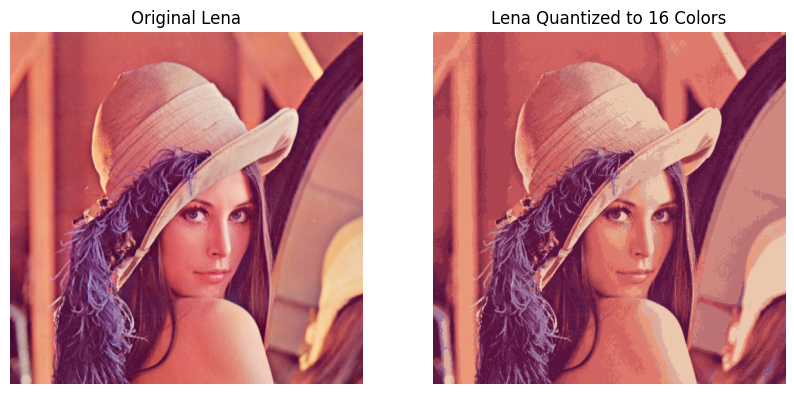

Total Final L2 Norm: 29.75


True

In [10]:
# Process image
lena_quantized, lena_l2_norms = kmeans_quantization(lena, k, max_iterations, visualize)

# Save L2 norms log
with open('L2_norm_log.txt', 'w') as f:
    f.write('Lena Quantization Error per Iteration:\n' + '\n'.join(map(str, lena_l2_norms)) + '\n')

# Calculate final L2 norm
lena_l2_final = calculate_l2_norm(lena, lena_quantized)

# Visualize results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena)
plt.title('Original Lena')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_quantized)
plt.title(f'Lena Quantized to {k} Colors')
plt.axis('off')

plt.show()

print(f'Total Final L2 Norm: {lena_l2_final:.2f}')

# Save quantized image (convert back to BGR for cv2)
lena_quantized_bgr = cv2.cvtColor((lena_quantized * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
cv2.imwrite('lena_quantized.png', lena_quantized_bgr)